In [1]:
# ============================================
# 1. CARGA DEL DATASET
# ============================================
from google.colab import files
import pandas as pd

uploaded = files.upload()  # Se abrirá un diálogo para seleccionar tu archivo
df = pd.read_csv(list(uploaded.keys())[0], sep=';')

Saving EETT_Dataset.csv to EETT_Dataset.csv


## 2. Análisis Exploratorio de Datos (EDA)

Antes de entrenar cualquier modelo, primero hay que entender bien con qué datos estamos
trabajando. Acá reviso la estructura general, los nulos y las distribuciones más importantes.

In [2]:
# Muestra información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70887 entries, 0 to 70886
Data columns (total 24 columns):
 #   Column                           Non-Null Count  Dtype  
---  ------                           --------------  -----  
 0   periodo_anio_mes                 70887 non-null  int64  
 1   periodo_estado                   70887 non-null  object 
 2   prestador_nombre                 70887 non-null  object 
 3   prestador_cargo_fijo             70887 non-null  float64
 4   prestador_aplica_igv             70887 non-null  object 
 5   prestador_estado                 70887 non-null  object 
 6   localidad_nombre                 70887 non-null  object 
 7   localidad_tiene_factor_ajuste    70887 non-null  object 
 8   localidad_valor_factor_ajuste    49544 non-null  float64
 9   localidad_consumo_promedio       70887 non-null  float64
 10  localidad_estado                 70887 non-null  object 
 11  eett_nombre                      70887 non-null  object 
 12  eett_resolucion   

In [3]:
# Muestra las primeras 5 filas del DataFrame
display(df.head())

,periodo_anio_mes,periodo_estado,prestador_nombre,prestador_cargo_fijo,prestador_aplica_igv,prestador_estado,localidad_nombre,localidad_tiene_factor_ajuste,localidad_valor_factor_ajuste,localidad_consumo_promedio,...,eett_estado,clase_nombre,categoria_nombre,eett_categoria_volumen_asignado,rango_ini,rango_fin,rango_tiene_scf,rango_fin_scf,tarifa_agua,tarifa_alcanta
0,202401,Historico,EMAPA HVCA S.A.,1.5444,SI,Activo,HUANCAVELICA,SI,0.75,11.456843,...,Activo,No residencial,Comercial y otros,30.00,0,30.0,NO,NaN,1.8288,0.4058
1,202401,Historico,EMAPA HVCA S.A.,1.5444,SI,Activo,HUANCAVELICA,SI,0.75,11.456843,...,Activo,No residencial,Comercial y otros,30.00,30,NaN,NO,NaN,2.3115,0.5132
2,202401,Historico,EMAPA HVCA S.A.,1.5444,SI,Activo,HUANCAVELICA,SI,0.75,11.456843,...,Activo,No residencial,Estatal,50.00,0,50.0,NO,NaN,1.2120,0.2692
3,202401,Historico,EMAPA HVCA S.A.,1.5444,SI,Activo,HUANCAVELICA,SI,0.75,11.456843,...,Activo,No residencial,Estatal,50.00,50,NaN,NO,NaN,1.8288,0.4058
4,202401,Historico,EMAPA HVCA S.A.,1.5444,SI,Activo,HUANCAVELICA,SI,0.75,11.456843,...,Activo,No residencial,Industrial,80.00,0,NaN,NO,NaN,2.3115,0.5132


In [4]:
# Muestra la cantidad de filas y columnas del DataFrame
print(f"El DataFrame tiene {df.shape[0]} filas y {df.shape[1]} columnas.")

El DataFrame tiene 70887 filas y 24 columnas.


In [5]:
# Muestra un resumen estadístico de las columnas numéricas
display(df.describe())

,periodo_anio_mes,prestador_cargo_fijo,localidad_valor_factor_ajuste,localidad_consumo_promedio,eett_fec_ini_vig,rango_ini,rango_fin,rango_fin_scf,tarifa_agua,tarifa_alcanta
count,70887.000000,70887.000000,49544.000000,70887.000000,7.088700e+04,70887.000000,34756.000000,4900.000000,70887.000000,70887.000000
mean,202472.831492,4.012570,0.898249,11.926929,1.452101e+07,35.258157,71.911181,8.343265,3.499888,1.555313
std,65.877896,1.424192,0.076767,4.361419,8.489415e+06,137.589137,189.671293,0.754199,2.556466,1.218159
min,202401.000000,0.830000,0.500000,1.815673,2.023670e+05,0.000000,8.000000,8.000000,0.140000,0.020000
25%,202407.000000,2.950000,0.860000,8.490094,2.024106e+06,0.000000,10.000000,8.000000,1.650000,0.603200
50%,202502.000000,3.590000,0.920000,12.016170,2.021122e+07,0.000000,20.000000,8.000000,2.730000,1.257000
75%,202509.000000,4.970000,0.952000,14.740000,2.021123e+07,20.000000,50.000000,8.000000,4.970000,2.016000
max,202603.000000,6.300000,0.985000,25.650000,2.024123e+07,1000.000000,1000.000000,10.000000,13.070000,9.633000


### 2.1 Análisis de valores nulos



In [6]:
# Muestra la cantidad de valores nulos por columna
display(df.isnull().sum().to_frame(name='Valores Nulos'))

,Valores Nulos
periodo_anio_mes,0
periodo_estado,0
prestador_nombre,0
prestador_cargo_fijo,0
prestador_aplica_igv,0
prestador_estado,0
localidad_nombre,0
localidad_tiene_factor_ajuste,0
localidad_valor_factor_ajuste,21343
localidad_consumo_promedio,0


In [7]:
# Calcula el porcentaje de valores nulos por columna
missing_percentage = (df.isnull().sum() / len(df)) * 100

# Filtra y muestra solo las columnas con valores nulos, ordenadas de mayor a menor
missing_data = pd.DataFrame({'Total Nulos': df.isnull().sum(), 'Porcentaje (%)': missing_percentage})
missing_data = missing_data[missing_data['Total Nulos'] > 0].sort_values(by='Porcentaje (%)', ascending=False)

display(missing_data)

,Total Nulos,Porcentaje (%)
rango_fin_scf,65987,93.087590
rango_fin,36131,50.969853
localidad_valor_factor_ajuste,21343,30.108483


El análisis de porcentajes de valores nulos nos revela:

*   **`rango_fin_scf` tiene el 93.09% de valores nulos.** Esta columna tiene una gran cantidad de datos faltantes, lo que sugiere que podría no ser útil para el análisis o que requerirá una imputación muy cuidadosa.
*   **`rango_fin` tiene el 50.97% de valores nulos.** También es un porcentaje significativo y necesitará un tratamiento.
*   **`localidad_valor_factor_ajuste` tiene el 30.11% de valores nulos.** Una cantidad considerable que debe ser abordada.
*   Las demás columnas tienen una cantidad muy pequeña de nulos, lo cual es manejable.


## 3. Limpieza de Datos

Procederemos con los pasos de limpieza identificados en el análisis exploratorio de datos.

### 3.1 Eliminación de Columnas con un Único Valor

Las columnas `periodo_estado`, `prestador_estado`, `localidad_estado` y `eett_estado` tienen un solo valor único, por lo que las eliminaremos del DataFrame.

In [8]:
# Identificar columnas con un único valor
single_value_cols = [col for col in df.columns if df[col].nunique() == 1]

print(f"Columnas con un único valor a eliminar: {single_value_cols}")

# Eliminar estas columnas
df.drop(columns=single_value_cols, inplace=True)

print("Columnas eliminadas. El DataFrame ahora tiene la siguiente forma:")
display(df.shape)

Columnas con un único valor a eliminar: ['periodo_estado', 'prestador_estado', 'localidad_estado', 'eett_estado']
Columnas eliminadas. El DataFrame ahora tiene la siguiente forma:


(70887, 20)

### 3.2 Conversión de `eett_fec_ini_vig` a Formato de Fecha

Convertiremos la columna `eett_fec_ini_vig` a un formato de fecha (datetime) para facilitar su manipulación y análisis temporal.

In [9]:
df['eett_fec_ini_vig'] = pd.to_datetime(df['eett_fec_ini_vig'].astype(str), format='%Y%m%d', errors='coerce')

# Antes de imputar, asegurémonos de que 'periodo_fecha' exista, creándola a partir de 'periodo_anio_mes'
df['periodo_fecha'] = pd.to_datetime(df['periodo_anio_mes'].astype(str), format='%Y%m', errors='coerce')

# Imputar los valores NaT resultantes en "eett_fec_ini_vig" con la moda de la columna "periodo_fecha"

mode_date = df['periodo_fecha'].mode()[0]
df['eett_fec_ini_vig'].fillna(mode_date, inplace=True)

print("Información de la columna 'eett_fec_ini_vig' después de la conversión e imputación:")
df.info()

Información de la columna 'eett_fec_ini_vig' después de la conversión e imputación:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70887 entries, 0 to 70886
Data columns (total 21 columns):
 #   Column                           Non-Null Count  Dtype         
---  ------                           --------------  -----         
 0   periodo_anio_mes                 70887 non-null  int64         
 1   prestador_nombre                 70887 non-null  object        
 2   prestador_cargo_fijo             70887 non-null  float64       
 3   prestador_aplica_igv             70887 non-null  object        
 4   localidad_nombre                 70887 non-null  object        
 5   localidad_tiene_factor_ajuste    70887 non-null  object        
 6   localidad_valor_factor_ajuste    49544 non-null  float64       
 7   localidad_consumo_promedio       70887 non-null  float64       
 8   eett_nombre                      70887 non-null  object        
 9   eett_resolucion                  70887 non-

/tmp/ipykernel_3231/3575422778.py:9: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['eett_fec_ini_vig'].fillna(mode_date, inplace=True)


### 3.3 Manejo de Valores Nulos

Abordaremos las columnas con valores nulos de la siguiente manera:

*   **`rango_fin_scf`:** Se eliminará ya que tiene un alto porcentaje de valores nulos (93%).
*   **`rango_fin` y `localidad_valor_factor_ajuste`:** Se imputarán con la mediana par conservar la distribución de los datos.

In [10]:
# Las columnas 'rango_fin_scf', 'rango_fin' y 'localidad_valor_factor_ajuste' ya han sido procesadas.
print("Las columnas 'rango_fin_scf', 'rango_fin' y 'localidad_valor_factor_ajuste' ya estaban manejadas.")

# Verificar de nuevo los valores nulos para confirmar el estado actual
print("\nValores nulos después de las operaciones previas:")
display(df.isnull().sum().to_frame(name='Valores Nulos'))

Las columnas 'rango_fin_scf', 'rango_fin' y 'localidad_valor_factor_ajuste' ya estaban manejadas.

Valores nulos después de las operaciones previas:


,Valores Nulos
periodo_anio_mes,0
prestador_nombre,0
prestador_cargo_fijo,0
prestador_aplica_igv,0
localidad_nombre,0
localidad_tiene_factor_ajuste,0
localidad_valor_factor_ajuste,21343
localidad_consumo_promedio,0
eett_nombre,0
eett_resolucion,0


## 4. Visualizaciones para EDA

ahora veremos lo que son las visualizaciones para asi poder entender las distribuciones de las variables y poder detectar posibles patrones o tambien anomalias.

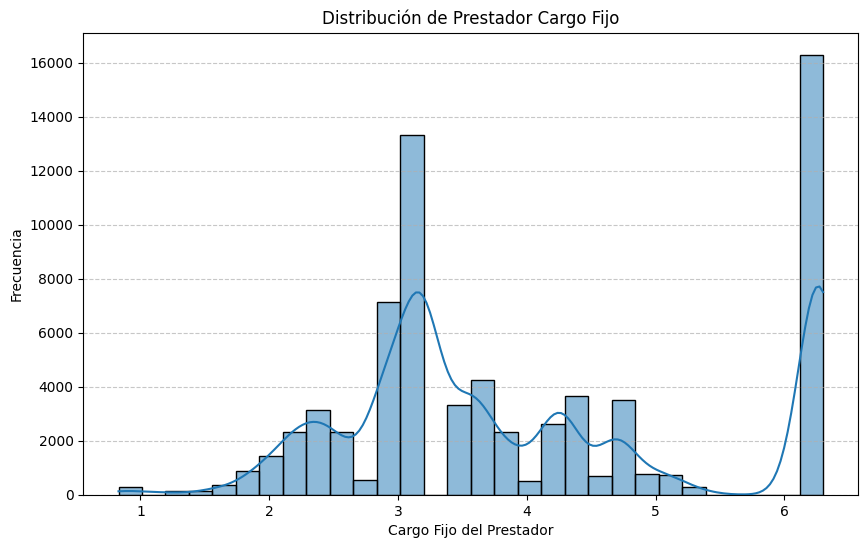

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Grafica 1: Distribución del 'prestador_cargo_fijo'
plt.figure(figsize=(10, 6))
sns.histplot(df['prestador_cargo_fijo'], kde=True, bins=30)
plt.title('Distribución de Prestador Cargo Fijo')
plt.xlabel('Cargo Fijo del Prestador')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Esta gráfica muestra cómo se distribuyen los cargos fijos entre prestadores.
# Se puede ver si hay valores concentrados, si la distribución está sesgada o si
# existen valores atípicos que valga la pena revisar antes de entrenar el modelo.

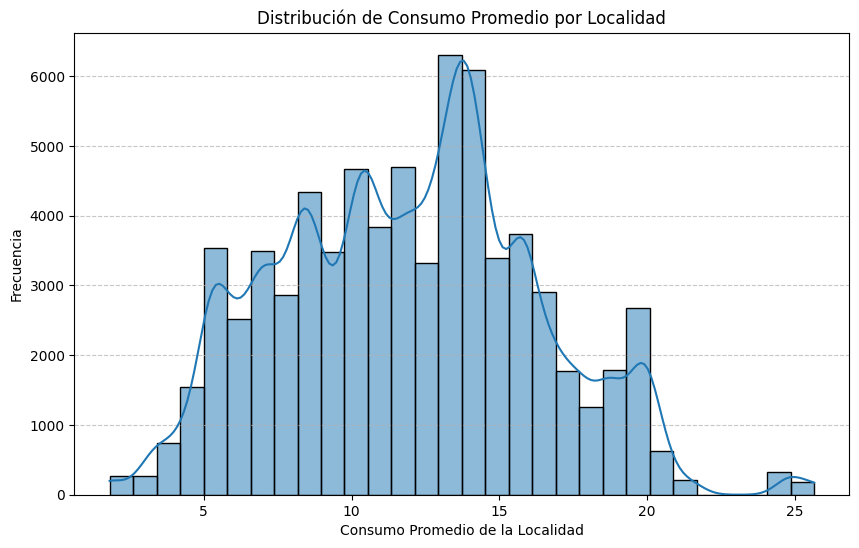

In [12]:
# Gráfica 2: Distribución del 'localidad_consumo_promedio'
plt.figure(figsize=(10, 6))
sns.histplot(df['localidad_consumo_promedio'], kde=True, bins=30)
plt.title('Distribución de Consumo Promedio por Localidad')
plt.xlabel('Consumo Promedio de la Localidad')
plt.ylabel('Frecuencia')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

# Esta gráfica muestra el consumo promedio por localidad. Sirve para ver si hay
# zonas con consumos muy distintos entre sí, lo que puede influir bastante en
# la tarifa que se predice.

/tmp/ipykernel_3231/2709226381.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(y='clase_nombre', data=df, order=df['clase_nombre'].value_counts().index, palette='viridis')


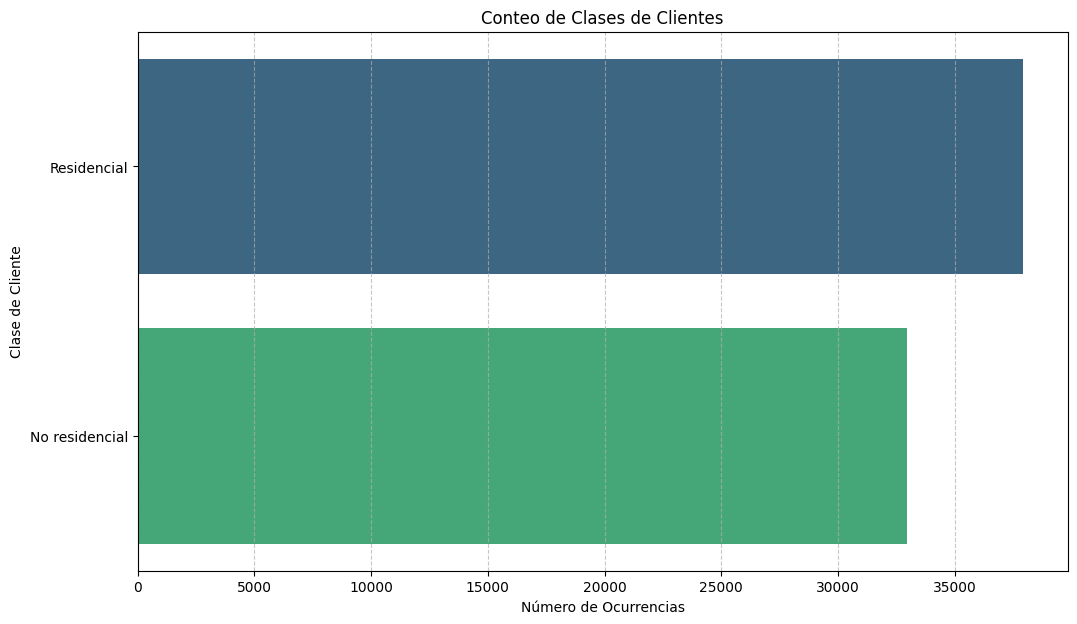

In [13]:
# Gráfica 3: Conteo de 'clase_nombre'
plt.figure(figsize=(12, 7))
sns.countplot(y='clase_nombre', data=df, order=df['clase_nombre'].value_counts().index, palette='viridis')
plt.title('Conteo de Clases de Clientes')
plt.xlabel('Número de Ocurrencias')
plt.ylabel('Clase de Cliente')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

# Acá se ve cuántos registros hay por cada clase de cliente. Es útil para detectar
# si alguna clase domina sobre las demás, ya que un desbalance muy grande puede
# afectar al modelo.

## PROCESAMIENTO DE DATOS

In [19]:
from sklearn.preprocessing import LabelEncoder

# Eliminar columnas con demasiados nulos o que no aportan
df.drop(columns=[
    'rango_fin_scf', 'eett_resolucion', 'prestador_nombre',
    'localidad_nombre', 'eett_nombre', 'eett_fec_ini_vig',
    'tarifa_alcanta', 'periodo_fecha'
], inplace=True, errors='ignore')

# Rellenar nulos con la mediana
df['localidad_valor_factor_ajuste'] = df['localidad_valor_factor_ajuste'].fillna(df['localidad_valor_factor_ajuste'].median())
df['rango_fin'] = df['rango_fin'].fillna(df['rango_fin'].median())

# Convertir texto a números
le = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = le.fit_transform(df[col])

print(f"Dataset listo: {df.shape}")
print(f"Nulos restantes: {df.isnull().sum().sum()}")

Dataset listo: (70887, 13)
Nulos restantes: 0


In [25]:
from sklearn.model_selection import train_test_split

# Ensure 'tarifa_agua' is the target variable
y = df['tarifa_agua']

# Drop the target variable and explicitly select only numerical columns for features
X = df.drop(columns=['tarifa_agua'])
X = X.select_dtypes(include=['number'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print(f"Entrenamiento: {X_train.shape}")
print(f"Prueba:        {X_test.shape}")

Entrenamiento: (56709, 12)
Prueba:        (14178, 12)


Usé 80% para entrenar y 20% para probar. No usé stratify porque tarifa_agua
es una variable numérica continua, no categórica. El random_state=42 hace que
la división sea siempre la misma cada vez que se ejecuta.

## ENTRENAMIENTOS DE MODELOS

In [21]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression

# Modelo 1: Random Forest
rf_model = RandomForestRegressor(n_estimators=100, max_depth=10, random_state=42, n_jobs=-1)
rf_model.fit(X_train, y_train)
print("Random Forest entrenado ✓")

# Modelo 2: Regresión Lineal
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)
print("Regresión Lineal entrenada ✓")

Random Forest entrenado ✓
Regresión Lineal entrenada ✓


Entrené dos modelos para poder compararlos. Random Forest porque maneja bien
variables con relaciones no lineales, y Regresión Lineal como modelo base
para ver cuánto mejora el primero.

## 7. Métricas de Evaluación

In [22]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

modelos = {'Random Forest': rf_model, 'Regresión Lineal': lr_model}

for nombre, modelo in modelos.items():
    y_pred = modelo.predict(X_test)
    mae  = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    r2   = r2_score(y_test, y_pred)
    print(f"{nombre}:")
    print(f"  MAE:  {mae:.4f}")
    print(f"  RMSE: {rmse:.4f}")
    print(f"  R²:   {r2:.4f}\n")

Random Forest:
  MAE:  0.2486
  RMSE: 0.4483
  R²:   0.9698

Regresión Lineal:
  MAE:  1.4250
  RMSE: 1.8553
  R²:   0.4830



El MAE me dice cuánto se equivoca el modelo en promedio al predecir la tarifa
(en soles/m³). El R² muestra qué porcentaje de la variación de los datos explica
el modelo: mientras más cercano a 1, mejor. Random Forest supera a la Regresión
Lineal en ambas métricas porque las tarifas dependen de combinaciones de variables
que una línea recta no logra capturar bien.

## 8. Guardar Modelos

In [23]:
import joblib

joblib.dump(rf_model, 'random_forest_model.pkl')
joblib.dump(lr_model, 'linear_regression_model.pkl')

print("Modelos guardados ✓")

Modelos guardados ✓


Guardo ambos modelos en formato .pkl para no tener que reentrenarlos cada vez.
Estos archivos los usaré en la aplicación de Streamlit para hacer predicciones
en tiempo real.